In [12]:
using Oceananigans
using Oceananigans.Units

In [13]:
grid = RectilinearGrid(topology = (Periodic, Periodic, Bounded),
                       size = (16, 8, 4),
                       x = (0, 64),
                       y = (0, 32),
                       z = (0, 8))

16×8×4 RectilinearGrid{Float64, Periodic, Periodic, Bounded} on CPU with 3×3×3 halo
├── Periodic x ∈ [0.0, 64.0) regularly spaced with Δx=4.0
├── Periodic y ∈ [0.0, 32.0) regularly spaced with Δy=4.0
└── Bounded  z ∈ [0.0, 8.0]  regularly spaced with Δz=2.0

In [14]:
znodes(grid, Center())

1.0:2.0:7.0

In [15]:
znodes(grid, Face())

0.0:2.0:8.0

In [16]:
xnodes(grid, Face())

0.0:4.0:60.0

In [17]:
architecture = CPU()
z_faces = [0, 1, 3, 6, 10]

grid = RectilinearGrid(architecture,
                       topology = (Periodic, Flat, Bounded),
                       size = (10, 4),
                       x = (0, 20),
                       z = z_faces)

10×1×4 RectilinearGrid{Float64, Periodic, Flat, Bounded} on CPU with 3×0×3 halo
├── Periodic x ∈ [0.0, 20.0) regularly spaced with Δx=2.0
├── Flat y                   
└── Bounded  z ∈ [0.0, 10.0] variably spaced with min(Δz)=1.0, max(Δz)=4.0

In [18]:
Δz = zspacings(grid, Center(), Center(), Center())
[Δz[1, 1, k] for k in 1:grid.Nz]

4-element Vector{Float64}:
 1.0
 2.0
 3.0
 4.0

In [19]:
grid = LambertConformalConicGrid(size = (8, 6, 1),
                                 center = (-105, 40),
                                 spacing = 20e3,
                                 standard_parallels = (30, 60),
                                 z = (-100, 0))

8×6×1 LambertConformalConicGrid{Float64, Bounded, Bounded, Bounded} on CPU with 3×3×1 halo
├── centered at (λ, φ) = (-105.0, 40.0)
├── longitude: Bounded  extent 1.48547 degrees variably spaced with min(Δλ)=0.185194, max(Δλ)=0.185537
├── latitude:  Bounded  extent 1.11223 degrees variably spaced with min(Δφ)=0.185194, max(Δφ)=0.185537
└── z:         Bounded  z ∈ [-100.0, 0.0]      regularly spaced with Δz=100.0

In [20]:
architecture = CPU()

grid = LatitudeLongitudeGrid(architecture,
                             size = (180, 10, 5),
                             longitude = (-180, 180),
                             latitude = (-60, 60),
                             z = (-1000, 0))

180×10×5 LatitudeLongitudeGrid{Float64, Periodic, Bounded, Bounded} on CPU with 3×3×3 halo
├── longitude: Periodic λ ∈ [-180.0, 180.0) regularly spaced with Δλ=2.0
├── latitude:  Bounded  φ ∈ [-60.0, 60.0]   regularly spaced with Δφ=12.0
└── z:         Bounded  z ∈ [-1000.0, 0.0]  regularly spaced with Δz=200.0

In [21]:
grid = RectilinearGrid(topology = (Bounded, Bounded, Bounded),
                       size = (20, 20, 20),
                       x = (-5kilometers, 5kilometers),
                       y = (-5kilometers, 5kilometers),
                       z = (0, 1kilometer))

# Height and width
H = 100meters
W = 1kilometer

mountain(x, y) = H * exp(-(x^2 + y^2) / 2W^2)
mountain_grid = ImmersedBoundaryGrid(grid, GridFittedBottom(mountain))

20×20×20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CPU with 3×3×3 halo:
├── immersed_boundary: GridFittedBottom(mean(z)=4.5, min(z)=0.0, max(z)=100.0)
├── underlying_grid: 20×20×20 RectilinearGrid{Float64, Bounded, Bounded, Bounded} on CPU with 3×3×3 halo
├── Bounded  x ∈ [-5000.0, 5000.0] regularly spaced with Δx=500.0
├── Bounded  y ∈ [-5000.0, 5000.0] regularly spaced with Δy=500.0
└── Bounded  z ∈ [0.0, 1000.0]     regularly spaced with Δz=50.0

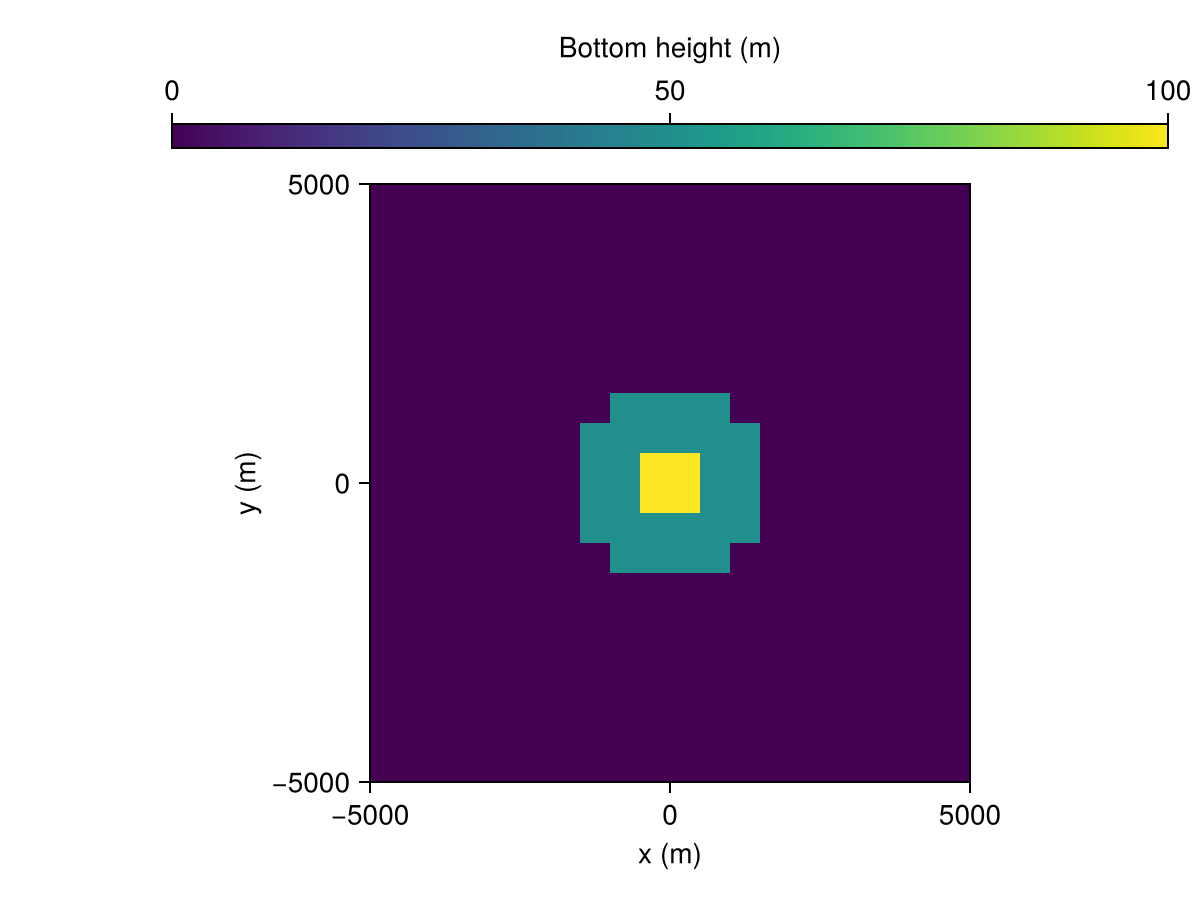

In [22]:
using CairoMakie

h = bottom_height_field(mountain_grid)

fig = Figure()
ax = Axis(fig[2, 1], xlabel="x (m)", ylabel="y (m)", aspect=1)
hm = heatmap!(ax, h)
Colorbar(fig[1, 1], hm, vertical=false, label="Bottom height (m)")

fig

In [23]:
big_halo_grid = RectilinearGrid(topology = (Periodic, Periodic, Flat),
                                size = (32, 16),
                                halo = (7, 7),
                                x = (0, 2π),
                                y = (0, π))

32×16×1 RectilinearGrid{Float64, Periodic, Periodic, Flat} on CPU with 7×7×0 halo
├── Periodic x ∈ [-6.90805e-17, 6.28319) regularly spaced with Δx=0.19635
├── Periodic y ∈ [-1.07194e-16, 3.14159) regularly spaced with Δy=0.19635
└── Flat z                               

In [24]:
Nx = Ny = 64
Nz = 32

Lx = Ly = 1e4
Lz = 1e3

# Note that j varies from 1 to Ny
chebychev_spaced_y_faces(j) = Ly * (1 - cos(π * (j - 1) / Ny)) / 2

# Note that k varies from 1 to Nz
chebychev_spaced_z_faces(k) = - Lz * (1 + cos(π * (k - 1) / Nz)) / 2

grid = RectilinearGrid(size = (Nx, Ny, Nz),
                       topology = (Periodic, Bounded, Bounded),
                       x = (0, Lx),
                       y = chebychev_spaced_y_faces,
                       z = chebychev_spaced_z_faces)

64×64×32 RectilinearGrid{Float64, Periodic, Bounded, Bounded} on CPU with 3×3×3 halo
├── Periodic x ∈ [0.0, 10000.0)  regularly spaced with Δx=156.25
├── Bounded  y ∈ [0.0, 10000.0]  variably spaced with min(Δy)=6.02272, max(Δy)=245.338
└── Bounded  z ∈ [-1000.0, -0.0] variably spaced with min(Δz)=2.40764, max(Δz)=49.0086

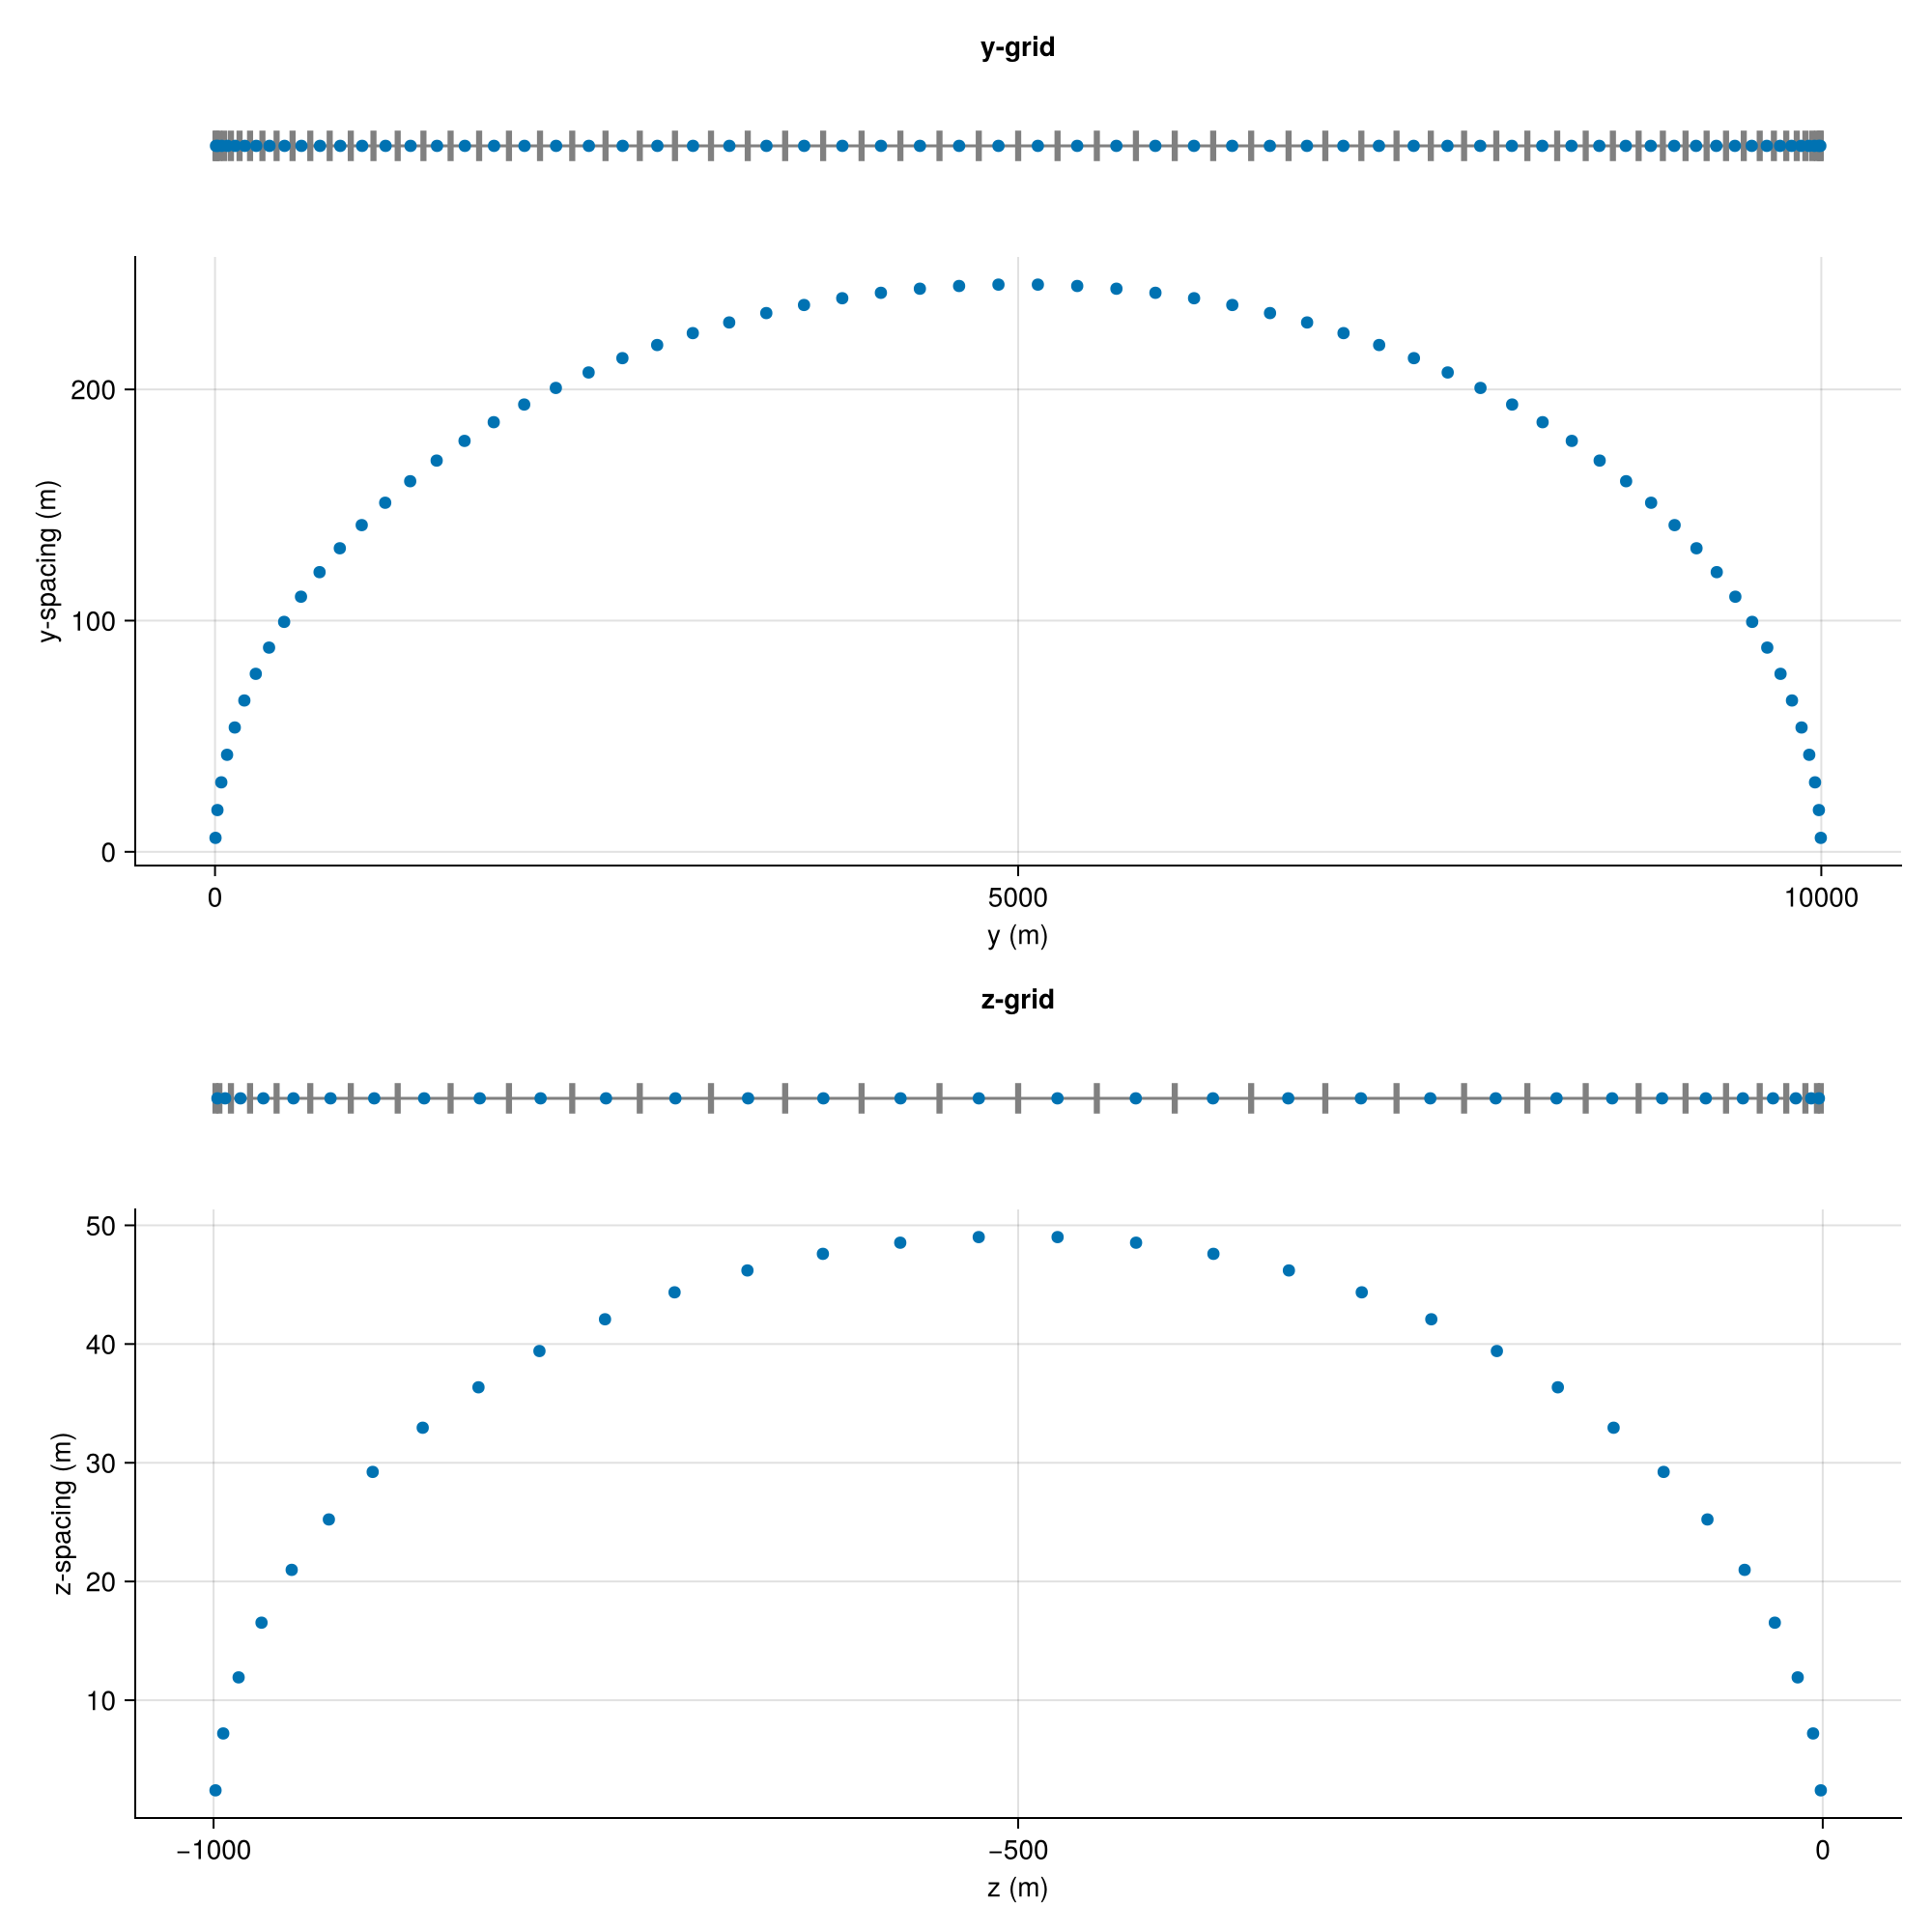

In [25]:
yc = ynodes(grid, Center())
zc = znodes(grid, Center())

yf = ynodes(grid, Face())
zf = znodes(grid, Face())

Δy = yspacings(grid, Center())
Δz = zspacings(grid, Center())

fig = Figure(size=(1000, 1000))

axy = Axis(fig[1, 1], title="y-grid")
lines!(axy, [0, Ly], [0, 0], color=:gray)
scatter!(axy, yf, 0 * yf, marker=:vline, color=:gray, markersize=25)
scatter!(axy, yc, 0 * yc)
hidedecorations!(axy)
hidespines!(axy)

axΔy = Axis(fig[2, 1]; xlabel = "y (m)", ylabel = "y-spacing (m)")
scatter!(axΔy, yc, Δy)
hidespines!(axΔy, :t, :r)

axz = Axis(fig[3, 1], title="z-grid")
lines!(axz, [-Lz, 0], [0, 0], color=:gray)
scatter!(axz, zf, 0 * zf, marker=:vline, color=:gray, markersize=25)
scatter!(axz, zc, 0 * zc)
hidedecorations!(axz)
hidespines!(axz)

axΔz = Axis(fig[4, 1]; xlabel = "z (m)", ylabel = "z-spacing (m)")
scatter!(axΔz, zc, Δz)
hidespines!(axΔz, :t, :r)

rowsize!(fig.layout, 1, Relative(0.1))
rowsize!(fig.layout, 3, Relative(0.1))

fig

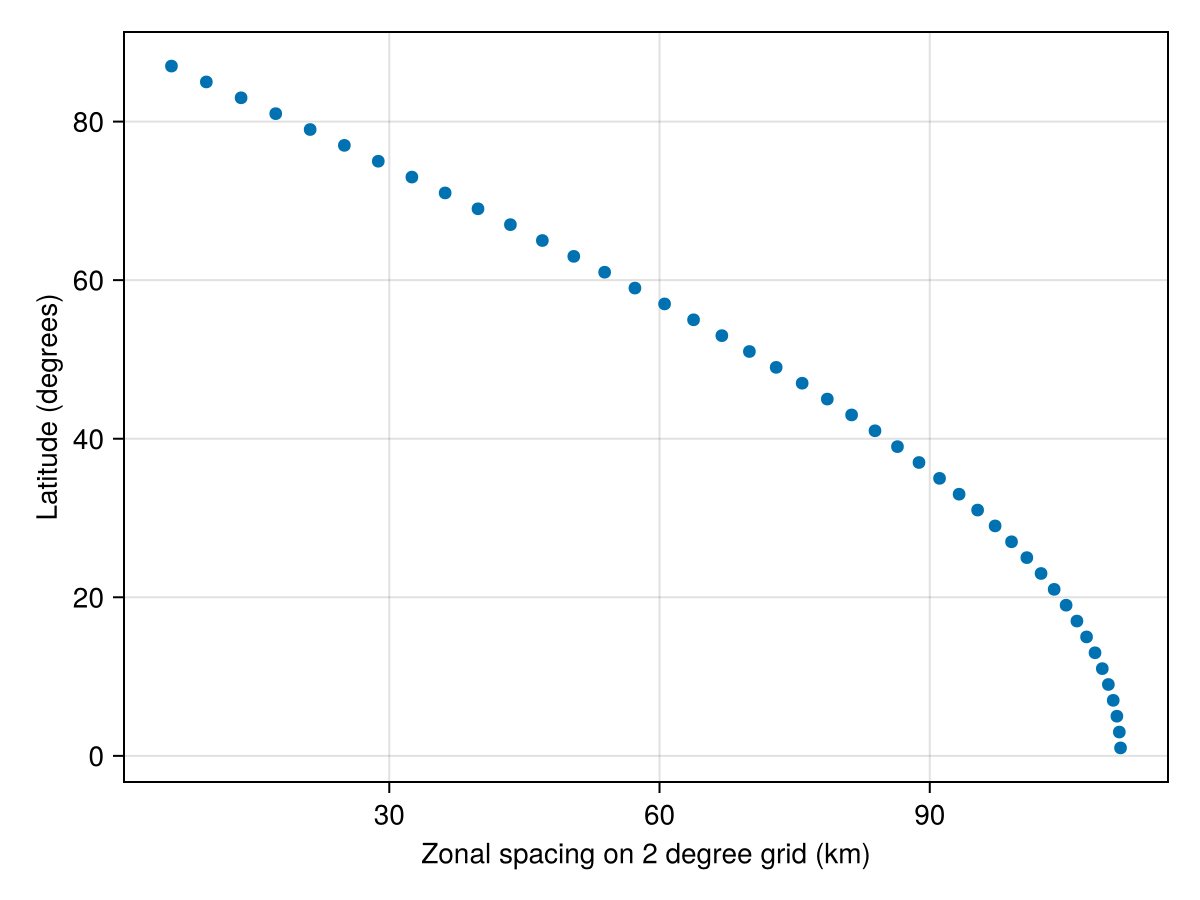

In [26]:
grid = LatitudeLongitudeGrid(size = (1, 44),
                             longitude = (0, 1),
                             latitude = (0, 88),
                             topology = (Bounded, Bounded, Flat))

Δx = xspacings(grid, Center(), Center())

fig = Figure()
ax = Axis(fig[1, 1], xlabel="Zonal spacing on 2 degree grid (km)", ylabel="Latitude (degrees)")
scatter!(ax, Δx / 1e3)
fig

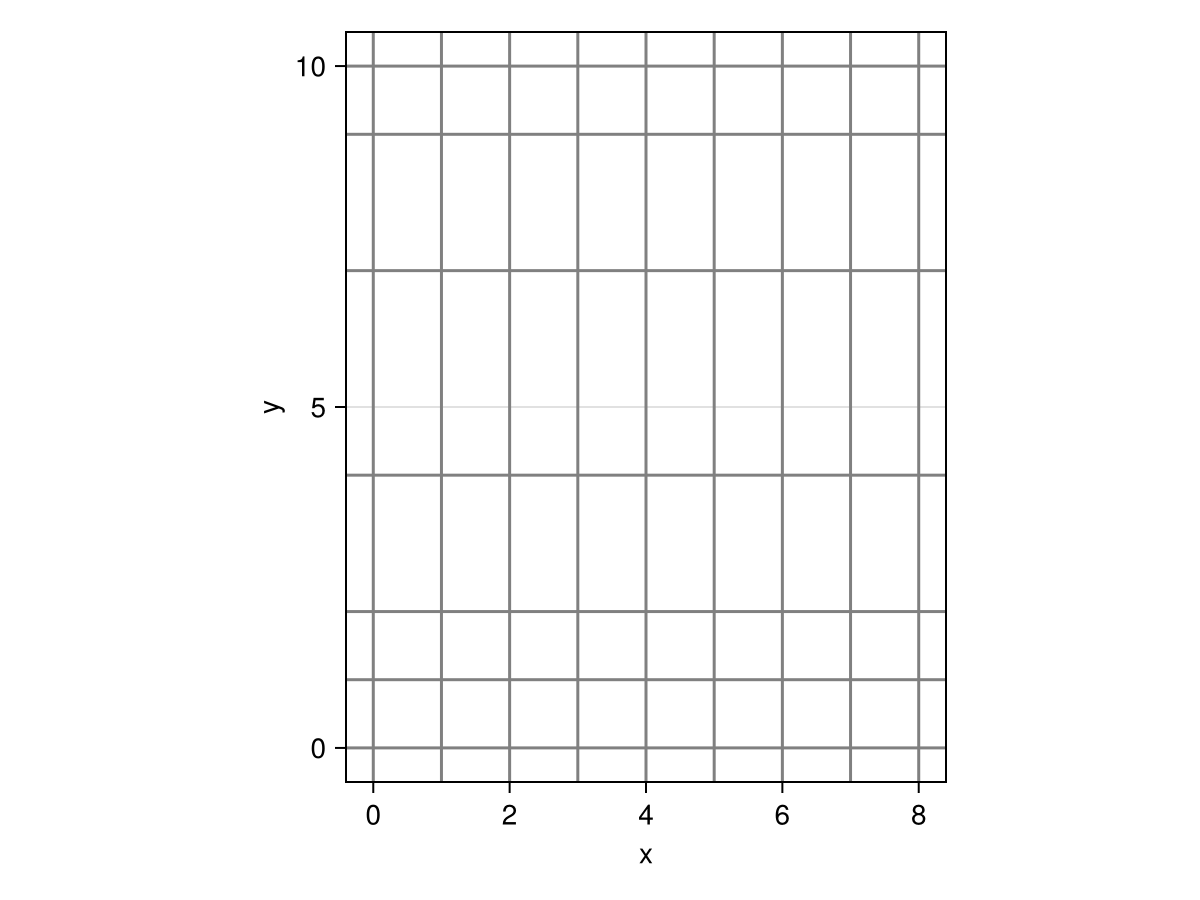

In [27]:
using Oceananigans, CairoMakie

grid = RectilinearGrid(size=(8, 6), x=(0, 8), y=[0, 1, 2, 4, 7, 9, 10], topology=(Bounded, Bounded, Flat))

xf = xnodes(grid, Face())
yf = ynodes(grid, Face())

fig = Figure()
ax = Axis(fig[1, 1], aspect = DataAspect(), xlabel = "x", ylabel = "y")

vlines!(ax, xf, color = :gray)
hlines!(ax, yf, color = :gray)

fig